# Clustering Analysis

Downstream analysis demonstrating clustering of extracted scientific data.
We cluster entity-attribute feature vectors from (a) ground truth, (b) full LLM
extraction, and (c) synthetic probe data, then measure how confidence-weighted
KMeans — using probe or NTP scores — aligns extracted clusters with ground truth.

In [1]:
import sys
from pathlib import Path
%load_ext autoreload
%autoreload 2

REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT / 'src'))
sys.path.insert(0, str(REPO_ROOT / 'experiments'))
sys.path.insert(0, str(REPO_ROOT))

from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from analysis.loaders import (
    load_combined_judgements, load_extraction, load_ground_truth,
    load_trained_probe, load_activations,
    load_synthetic_responses, load_synthetic_activations,
)
from scholarlm.utils.unit_conversion import apply_unit_conversion
from experiments.run_extraction import load_dataset_config
import paths

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "legend.fontsize": 8, "legend.title_fontsize": 9,
    "axes.linewidth": 0.6,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.major.size": 3, "ytick.major.size": 3,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "lines.linewidth": 1.2, "lines.markersize": 4,
    "legend.frameon": False,
    "figure.dpi": 150, "savefig.dpi": 300,
    "savefig.format": "pdf", "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

# blue: 7, orange: 1, red: 0, green: 4
palette = sns.color_palette("husl", 10)

FIGURES_DIR = Path("../figures/clustering/")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

/projectnb/mcnet/kevin/coastal/scholarlm/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Parameters ───────────────────────────────────────────────────────────────
DATASET          = 'pond'
EXTRACTION_MODEL = 'gemma-3-27b'
EXTRACTION_DATE  = '2026_05_05'
JUDGE_MODEL      = 'llama-3.1-8b'
JUDGE_DATE       = '2026_05_06'
SYN_JUDGE_DATE   = '2026_05_04'  # date for synthetic probe activations

N_CLUSTERS = 5  # chosen from elbow curve below

## 1. Load Raw Data

In [43]:
config  = load_dataset_config(DATASET)
gt_df   = load_ground_truth(config)
records = load_extraction(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE)
ext_df  = pd.DataFrame(records)
syn_responses = load_synthetic_responses(DATASET, JUDGE_MODEL, SYN_JUDGE_DATE, split='test')
syn_df  = pd.DataFrame(syn_responses)

# Unit conversion
gt_df  = apply_unit_conversion(gt_df,  config.unit_conversion_table)
ext_df = apply_unit_conversion(ext_df, config.unit_conversion_table)
syn_df = apply_unit_conversion(syn_df, config.unit_conversion_table)

# Ground truth and synthetic need a synthetic entity_id (ext_df already carries one)
_GT_ENTITY_COLS = ['document_id', 'name', 'location', 'ecosystem']
gt_df['entity_id'] = gt_df.groupby(_GT_ENTITY_COLS, dropna=False).ngroup()

_SYN_ENTITY_COLS = ['document_id', 'name', 'location', 'ecosystem']
syn_df['entity_id'] = syn_df.groupby(_SYN_ENTITY_COLS, dropna=False).ngroup()

print(f"Loaded: gt={len(gt_df):,} rows  |  ext={len(ext_df):,} rows  |  syn={len(syn_df):,} rows")
print(f"Entities — GT: {gt_df['entity_id'].nunique():,},  "
      f"Ext: {ext_df['entity_id'].nunique():,},  "
      f"Syn: {syn_df['entity_id'].nunique():,}")
print(f"Attributes: {sorted(gt_df['attribute'].unique())}")

Loaded: gt=3,333 rows  |  ext=10,951 rows  |  syn=4,620 rows
Entities — GT: 1,199,  Ext: 1,314,  Syn: 982
Attributes: ['chla', 'max_depth', 'ph', 'surface_area', 'tn', 'tp', 'vegetation_cover']


## 2. Filter Probe Training Documents

The probe was trained on synthetic measurements derived from a specific set of papers.
We remove those papers from all three datasets before clustering to prevent in-sample bias.

In [44]:
pd_data     = load_trained_probe(DATASET, JUDGE_MODEL, ptype = "head")
syn_doc_ids = set(pd_data['syn_document_ids'])
top_k       = pd_data['top_k_heads']

n_gt_before  = len(gt_df)
n_ext_before = len(ext_df)
n_syn_before = len(syn_df)

gt_df  = gt_df[ ~gt_df['document_id'].isin(syn_doc_ids)].reset_index(drop=True)
ext_df = ext_df[~ext_df['document_id'].isin(syn_doc_ids)].reset_index(drop=True)
syn_df = syn_df[~syn_df['document_id'].isin(syn_doc_ids)].reset_index(drop=True)

syn_df['label'] = syn_df['label'].map({'valid': True, 'invalid': False})

# Recompute entity_id for gt after row removal (ngroup values shift)
#gt_df['entity_id'] = gt_df.groupby(_GT_ENTITY_COLS, dropna=False).ngroup()

print(f"Probe trained on {len(syn_doc_ids)} documents.")
print(f"Row counts after filtering:")
print(f"  GT : {n_gt_before:,} → {len(gt_df):,}  ({n_gt_before - len(gt_df):,} removed)")
print(f"  Ext: {n_ext_before:,} → {len(ext_df):,}  ({n_ext_before - len(ext_df):,} removed)")
print(f"  Syn: {n_syn_before:,} → {len(syn_df):,}  ({n_syn_before - len(syn_df):,} removed)")

Probe trained on 48 documents.
Row counts after filtering:
  GT : 3,333 → 1,540  (1,793 removed)
  Ext: 10,951 → 4,157  (6,794 removed)
  Syn: 4,620 → 4,620  (0 removed)


## 3. Data Quality

Inspect missing rates per attribute.

In [7]:
_attrs = sorted(gt_df['attribute'].unique())

def _miss_rates(df, attrs):
    piv = df.pivot_table(index='entity_id', columns='attribute',
                         values='converted_value', aggfunc='first')
    piv = piv.reindex(columns=attrs)
    return piv.isna().mean(), len(piv)

gt_miss,  n_gt_ent  = _miss_rates(gt_df,  _attrs)
ext_miss, n_ext_ent = _miss_rates(ext_df, _attrs)
syn_miss, n_syn_ent = _miss_rates(syn_df, _attrs)

miss_summary = pd.DataFrame({
    'GT missing':  gt_miss,
    'Ext missing': ext_miss,
    'Syn missing': syn_miss,
}).round(3)
print("Missing rate per attribute (fraction of entities):")
print(miss_summary.to_string())
print(f"\nEntity counts — GT: {n_gt_ent:,},  Ext: {n_ext_ent:,},  Syn: {n_syn_ent:,}")

Missing rate per attribute (fraction of entities):
                  GT missing  Ext missing  Syn missing
attribute                                             
chla                   0.691        0.651        0.744
max_depth              0.577        0.393        0.654
ph                     0.667        0.633        0.724
surface_area           0.211        0.148        0.351
tn                     0.785        0.798        0.818
tp                     0.732        0.652        0.783
vegetation_cover       0.885        0.807        0.899

Entity counts — GT: 627,  Ext: 667,  Syn: 982


Here we find the maximum (i.e. largest $n\times d$) submatrix to keep for clustering (this way we avoid imputation). 

In [8]:
# 1. Setup
THRESHOLD = 0.20
# Pivot data (ensure no dropna yet)
gt_wide = gt_df.pivot_table(index='entity_id', columns='attribute', values='converted_value', aggfunc='first')

results = []

# 2. Iterate through column combinations (d=2 to 5)
for d in range(2, 6):
    for cols in combinations(gt_wide.columns, d):
        # Start with all rows for these specific columns
        submatrix = gt_wide[list(cols)].copy()
        
        # Iteratively drop the row with the most NaNs until total missingness < 10%
        while (submatrix.isna().sum().sum() / submatrix.size) > THRESHOLD:
            if submatrix.shape[0] <= 1: break # Safety break
            
            # Find row index with highest missing count
            worst_row = submatrix.isna().sum(axis=1).idxmax()
            submatrix = submatrix.drop(index=worst_row)
        
        # Record the largest valid version of this column set
        n_rows = submatrix.shape[0]
        actual_missing = submatrix.isna().sum().sum() / submatrix.size
        
        results.append({
            'attributes': list(cols),
            'd': d,
            'n_rows': n_rows,
            'missing_pct': actual_missing,
            'score': n_rows * d  # Area of the submatrix
        })

# 3. Process and Print
res_df = pd.DataFrame(results)
best = res_df.sort_values('score', ascending=False).iloc[0]

print(f"── Top Submatrices (Total Missingness < {THRESHOLD}) ──")
print(res_df.sort_values('score', ascending=False).head(10).to_string(index=False))

print(f"Best (near) complete submatrix:")
print(f"Attributes: {best['attributes']}")
print(f"Dimensions: {best['n_rows']} rows × {best['d']} cols")
print(f"Final Missingness: {best['missing_pct']:.2%}")
print(f"Total Area (n×d): {best['score']}")

── Top Submatrices (Total Missingness < 0.2) ──
                          attributes  d  n_rows  missing_pct  score
    [chla, ph, surface_area, tn, tp]  5     166     0.200000    830
                  [chla, ph, tn, tp]  4     187     0.199198    748
        [chla, surface_area, tn, tp]  4     182     0.197802    728
           [max_depth, surface_area]  2     361     0.199446    722
        [chla, ph, surface_area, tp]  4     166     0.198795    664
[chla, ph, tn, tp, vegetation_cover]  5     130     0.200000    650
       [chla, max_depth, ph, tn, tp]  5     129     0.200000    645
                      [chla, tn, tp]  3     207     0.199678    621
                      [chla, ph, tp]  3     201     0.199005    603
        [chla, ph, surface_area, tn]  4     150     0.200000    600
Best (near) complete submatrix:
Attributes: ['chla', 'ph', 'surface_area', 'tn', 'tp']
Dimensions: 166 rows × 5 cols
Final Missingness: 20.00%
Total Area (n×d): 830


## 4. Feature Matrices

Build entity × attribute wide-format matrices for GT, extraction, and synthetic data.

**Alignment note**: Judge probabilities (NTP and probe) are merged into `ext_df` and
`syn_df` by `measurement_id` *before* pivoting, so all three value columns (numeric
value, NTP probability, probe probability) use the same `aggfunc='first'` selection
per entity × attribute cell — guaranteeing exact row-level alignment.

In [9]:
# ── Load judge data; compute probe probabilities for extraction ───────────────
judge_df = pd.DataFrame(load_combined_judgements(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE))
judge_df = judge_df[~judge_df['document_id'].isin(syn_doc_ids)].reset_index(drop=True)

act      = load_activations(DATASET, EXTRACTION_MODEL, EXTRACTION_DATE, JUDGE_MODEL, JUDGE_DATE)
mids_ext = judge_df['measurement_id'].tolist()
X_feat_ext = np.concatenate([
    np.stack([np.array(act[str(mid)], dtype=np.float32)[l, h, :] for mid in mids_ext], axis=0)
    for l, h in top_k
], axis=1)
judge_df['p_probe'] = pd_data['probe'].predict_proba(X_feat_ext)[:, 1]

# Merge judge probs into ext_df so pivoting stays aligned
ext_df = ext_df.merge(
    judge_df[['measurement_id', f'judgement_p_true_{JUDGE_MODEL}', 'p_probe', 'judgement_combined']],
    on='measurement_id', how='left',
)

# ── Compute probe probabilities for synthetic data ─────────────────────────────
syn_act  = load_synthetic_activations(DATASET, JUDGE_MODEL, SYN_JUDGE_DATE, split='test')
mids_syn = syn_df['measurement_id'].tolist()
X_feat_syn = np.concatenate([
    np.stack([np.array(syn_act[str(mid)], dtype=np.float32)[l, h, :] for mid in mids_syn], axis=0)
    for l, h in top_k
], axis=1)
syn_df['p_probe'] = pd_data['probe'].predict_proba(X_feat_syn)[:, 1]

In [10]:
# ── Pivot all datasets onto keep_attrs (set by enumeration cell above) ─────────

def _pivot(df, value_col):
    piv = df.pivot_table(index='entity_id', columns='attribute',
                         values=value_col, aggfunc='first')
    piv.columns.name = None
    return piv.reindex(columns=keep_attrs)

def get_dense_submatrix(df_piv, threshold):
    """Drops the row with the most NaNs until the total missingness is below threshold."""
    dense_df = df_piv.copy()
    while (dense_df.isna().sum().sum() / dense_df.size) > threshold:
        if dense_df.shape[0] <= 1: break
        worst_row = dense_df.isna().sum(axis=1).idxmax()
        dense_df = dense_df.drop(index=worst_row)
    return dense_df

# 2. Pivot all datasets onto keep_attrs (from your Cell 8/11 winner)
keep_attrs = best['attributes']

gt_val_piv    = _pivot(gt_df,  'converted_value')
ext_val_piv   = _pivot(ext_df, 'converted_value')
syn_val_piv   = _pivot(syn_df, 'converted_value')

# Pivot the probability matrices
ext_ntp_piv   = _pivot(ext_df, f'judgement_p_true_{JUDGE_MODEL}')
ext_probe_piv = _pivot(ext_df, 'p_probe')
syn_ntp_piv   = _pivot(syn_df, 'judgement_p_true')
syn_probe_piv = _pivot(syn_df, 'p_probe')

# Pivot the label matrices
ext_label_piv = _pivot(ext_df, 'judgement_combined')
syn_label_piv = _pivot(syn_df, 'label')

# 3. Apply Independent Greedy Filtering
# We use the same THRESHOLD (e.g., 0.10) for all
gt_val_piv  = get_dense_submatrix(gt_val_piv, THRESHOLD)
ext_val_piv = get_dense_submatrix(ext_val_piv, THRESHOLD)
syn_val_piv = get_dense_submatrix(syn_val_piv, THRESHOLD)

# 4. Reindex probabilities to match the rows that survived the greedy drop
ext_ntp_piv   = ext_ntp_piv.reindex(ext_val_piv.index)
ext_probe_piv = ext_probe_piv.reindex(ext_val_piv.index)
syn_ntp_piv   = syn_ntp_piv.reindex(syn_val_piv.index)
syn_probe_piv = syn_probe_piv.reindex(syn_val_piv.index)

# Pivot the label matrices
ext_label_piv = ext_label_piv.reindex(ext_val_piv.index)
syn_label_piv = syn_label_piv.reindex(syn_val_piv.index)

print(f"Entities — GT: {len(gt_val_piv):,}, Ext: {len(ext_val_piv):,}, Syn: {len(syn_val_piv):,}")

Entities — GT: 166, Ext: 199, Syn: 169


In [11]:
def process_matrix(df_piv):
    # Independent imputer and scaler for each dataset
    imp = KNNImputer(n_neighbors=5, weights='distance')
    scl = StandardScaler()
    
    # Impute missing values (<10%) based on internal neighbors
    imputed = imp.fit_transform(df_piv)
    # Scale based on the internal distribution of this specific dataset
    return scl.fit_transform(imputed)

# Apply independently
X_gt  = process_matrix(gt_val_piv)
X_ext = process_matrix(ext_val_piv)
X_syn = process_matrix(syn_val_piv)

# ── Entity-level probabilities ──
def _entity_probs(prob_piv):
    # Fill missing enries with prob=1.0, so imputation does not affect later results
    return prob_piv.prod(axis=1, min_count=1).fillna(0.0).to_numpy()

ext_ntp_probs = _entity_probs(ext_ntp_piv)
ext_probe_probs = _entity_probs(ext_probe_piv)
syn_ntp_probs = _entity_probs(syn_ntp_piv)
syn_probe_probs = _entity_probs(syn_probe_piv)


# ── Label averages ──
def _entity_labels(label_piv):
    # Fill missing enries with prob=1.0, so imputation does not affect later results
    return label_piv.mean(axis=1).fillna(0.0).to_numpy()

ext_labels = _entity_labels(ext_label_piv)
syn_labels = _entity_labels(syn_label_piv)

print(f"Feature matrix shapes — GT: {X_gt.shape}, Ext: {X_ext.shape}, Syn: {X_syn.shape}")

Feature matrix shapes — GT: (166, 5), Ext: (199, 5), Syn: (169, 5)


/scratch/5608501.1.csdata/ipykernel_418462/1847625900.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return label_piv.mean(axis=1).fillna(0.0).to_numpy()


In [13]:
np.mean(ext_labels)

0.7010887772194304

## 5. Clustering

Fit KMeans on the ground-truth entities to define reference cluster centroids, then
sweep the weight exponent γ and measure how well confidence-weighted KMeans on the
extracted / synthetic data recovers those centroids.

**Centroid matching distance**: mean distance under the optimal (Hungarian) assignment
between GT centroids and extracted centroids.

In [14]:
def centroid_matching_distance(A, B, metric='euclidean'):
    """Mean optimal-assignment distance between two sets of centroids."""
    D = cdist(A, B, metric=metric)
    row_ind, col_ind = linear_sum_assignment(D, maximize=False)
    return D[row_ind, col_ind].mean()


def random_centroids(X, k, rng=None):
    """Draw k centroids uniformly from the bounding box of X."""
    rng = np.random.default_rng(rng)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    return rng.uniform(mins, maxs, size=(k, X.shape[1]))

def random_baseline_distance(X, k, true_centers, metric='euclidean', n_trials=100, rng=None):
    """Expected centroid_matching_distance from random centroids to true centers."""
    rng = np.random.default_rng(rng)
    distances = np.empty(n_trials)
    for i in range(n_trials):
        A = random_centroids(X, k, rng=rng)
        distances[i] = centroid_matching_distance(A, true_centers, metric=metric)
    return distances.mean(), distances.std()

In [15]:
N_CLUSTERS = 5

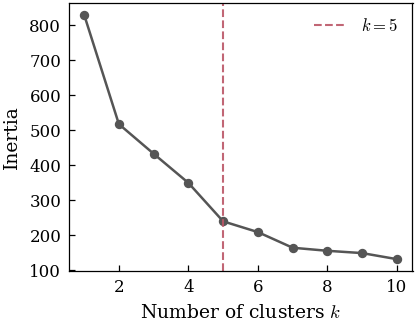

In [16]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_gt)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(3.0, 2.4))
ax.plot(list(k_range), inertia, 'o-', ms=3.5, lw=1.2, color='#555555')
ax.axvline(N_CLUSTERS, lw=1.0, ls='--', color='#BB5566', alpha=0.9,
           label=f'$k = {N_CLUSTERS}$')
ax.set_xlabel('Number of clusters $k$')
ax.set_ylabel('Inertia')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

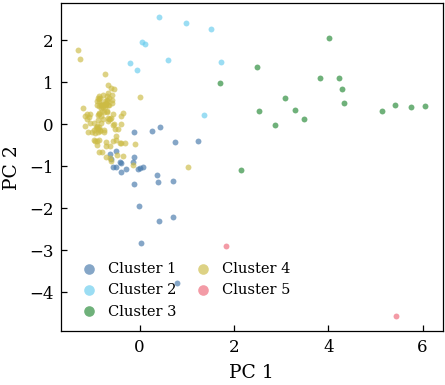

In [17]:
kmeans_gt  = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
gt_labels  = kmeans_gt.fit_predict(X_gt)
gt_centers = kmeans_gt.cluster_centers_

pca     = PCA(n_components=2)
X_gt_2d = pca.fit_transform(X_gt)

_CLUSTER_COLORS = [
    '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377',
    '#BBBBBB', '#44AA99', '#EE8866', '#AAAADD',
][:N_CLUSTERS]

fig, ax = plt.subplots(figsize=(3.2, 2.8))
for k in range(N_CLUSTERS):
    mask = gt_labels == k
    ax.scatter(X_gt_2d[mask, 0], X_gt_2d[mask, 1],
               c=_CLUSTER_COLORS[k], s=8, alpha=0.65, lw=0,
               label=f'Cluster {k + 1}')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(fontsize=7, markerscale=1.8, ncol=2, loc='best',
          handletextpad=0.3, columnspacing=0.8, borderpad=0.4)
fig.tight_layout()
plt.show()

In [41]:
kmeans_gt  = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
gt_labels  = kmeans_gt.fit_predict(X_gt)
gt_centers = kmeans_gt.cluster_centers_

N_RUNS = 1000  # Number of different initializations
gamma_vals = np.linspace(0.0, 5.0, 101)

_sweep_configs = {
    'ext_ntp':   (X_ext, ext_ntp_probs),
    'ext_probe': (X_ext, ext_probe_probs),
    'syn_ntp' : (X_syn , syn_ntp_probs),
    'syn_probe' : (X_syn , syn_probe_probs),
}

# Initialize a 2D array to store distances for each run: [run, gamma_index]
all_runs_dist = {k: np.zeros((N_RUNS, len(gamma_vals))) for k in _sweep_configs}

for run_idx in range(N_RUNS):
    current_seed = 42 + run_idx # Ensure a different seed per run

    for i, gamma in enumerate(gamma_vals):
        for key, (X, probs) in _sweep_configs.items():
            km = KMeans(n_clusters=N_CLUSTERS, random_state=current_seed, n_init='auto')
            km.fit(X, sample_weight=probs ** gamma)

            dist = centroid_matching_distance(gt_centers, km.cluster_centers_)
            all_runs_dist[key][run_idx, i] = dist

# Random baselines: N_RANDOM_SAMPLES draws of uniform random probs; each draw uses
# its own KMeans seed, collapsing both sources of variance into one loop.
N_RANDOM_SAMPLES = 1000
random_runs_dist = {
    'ext_random': np.zeros((N_RANDOM_SAMPLES, len(gamma_vals))),
    'syn_random': np.zeros((N_RANDOM_SAMPLES, len(gamma_vals))),
}
for sample_idx in range(N_RANDOM_SAMPLES):
    rng = np.random.default_rng(sample_idx)
    ext_random_probs = rng.uniform(0, 1, size=len(X_ext))
    syn_random_probs = rng.uniform(0, 1, size=len(X_syn))
    for i, gamma in enumerate(gamma_vals):
        for key, X, rprobs in [('ext_random', X_ext, ext_random_probs),
                               ('syn_random', X_syn, syn_random_probs)]:
            km = KMeans(n_clusters=N_CLUSTERS, random_state=sample_idx, n_init='auto')
            km.fit(X, sample_weight=rprobs ** gamma)
            dist = centroid_matching_distance(gt_centers, km.cluster_centers_)
            random_runs_dist[key][sample_idx, i] = dist

# Calculate mean and standard deviation
avg_distances = {k: np.mean(v, axis=0) for k, v in all_runs_dist.items()}
std_distances = {k: np.std(v, axis=0) / np.sqrt(N_RUNS) for k, v in all_runs_dist.items()}
for key, v in random_runs_dist.items():
    avg_distances[key] = v.mean(axis=0)
    std_distances[key] = v.std(axis=0) / np.sqrt(N_RANDOM_SAMPLES)

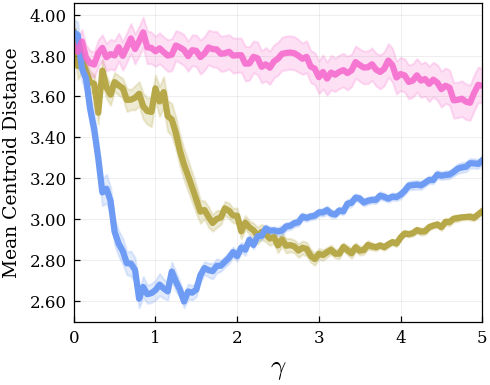

In [47]:
_STYLE = {
    'ext_ntp':     dict(color=palette[2], ls='-', lw=3.0, alpha=0.85,
                       label='Ext. NTP'),
    'ext_probe':   dict(color=palette[7], ls='-',  lw=3.0,
                       label='Ext. Probe'),
    'ext_random':  dict(color=palette[9], ls='-',  lw=3.0, alpha=0.85,
                       label='Ext. Random'),
    #'syn_ntp':     dict(color=palette[7], ls='--', lw=2.0, alpha=0.85,
    #                   label='Syn. NTP'),
    #'syn_probe':   dict(color=palette[7], ls='-',  lw=2.0,
    #                   label='Syn. Probe'),
    #'syn_random':  dict(color=palette[7], ls=':',  lw=2.0, alpha=0.85,
    #                   label='Syn. Random'),
}

fig, ax = plt.subplots(figsize=(3.5, 2.8))

for key, style in _STYLE.items():
    # Plot the mean line
    ax.plot(gamma_vals, avg_distances[key], **style)
    # Optional: Plot the shaded error region (standard error)

    ax.fill_between(
        gamma_vals, 
        avg_distances[key] - std_distances[key], 
        avg_distances[key] + std_distances[key], 
        color=style['color'], 
        alpha=0.2
    )

ax.grid(alpha=0.25, linestyle='-', linewidth=0.4)
ax.set_xlabel('$\\gamma$', fontsize = 13)
ax.set_ylabel('Mean Centroid Distance')
ax.set_xlim(gamma_vals[0], gamma_vals[-1])
#ax.legend(fontsize=6.5, loc='upper right', bbox_to_anchor=(1.0, 0.95))
ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter('%.2f'))
fig.tight_layout()

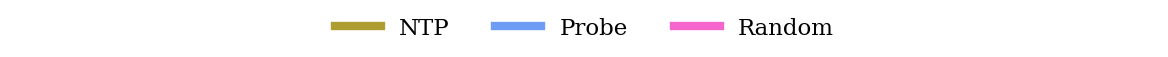

In [50]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

_legend_handles = [
    mlines.Line2D([], [], color=palette[2], lw=4, linestyle = "-", ms=3.5, label='NTP'),
    mlines.Line2D([], [], color=palette[7], lw=4, linestyle = "-", ms=3.5, label='Probe'),
    mlines.Line2D([], [], color=palette[9], lw=4, linestyle = "-", ms=3.5, label='Random'),
    #mlines.Line2D([], [], color='#444444', lw=2, linestyle='-',  label='Probe'),
    #mlines.Line2D([], [], color='#444444', lw=2, linestyle='--', label='NTP'),
    #mlines.Line2D([], [], color='#444444', lw=2, linestyle=':', label='Random'),
]
_fig_leg, _ax_leg = plt.subplots(figsize=(10.0, 0.45))
_ax_leg.axis('off')
_ax_leg.legend(handles=_legend_handles, loc='center', ncol=6, fontsize=11,
               frameon=False, handlelength=2.0)
#_fig_leg.savefig(FIGURES_DIR / 'legend.pdf', bbox_inches='tight', dpi=200)
plt.show()